# 📌 Step 1 — Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#Encoding
from sklearn.preprocessing import LabelEncoder

#Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# 📌 Step 2 — Load Dataset

In [2]:
df = pd.read_csv("DECISION TREE-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 📌 Step 3 — Dataset Information

In [3]:
print("Dataset Shape :", df.shape)

Dataset Shape : (1470, 35)


In [4]:
print("Columns in Dataset:")
print(df.columns)

Columns in Dataset:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [5]:
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  Job

# 📌 Step 4 — Check Missing Values

In [6]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# 📌 Step 5 — Statistical Summary

In [7]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

# 📌 Step 6 — Check Attrition Distribution

In [8]:
print(df['Attrition'].value_counts())

No     1233
Yes     237
Name: Attrition, dtype: int64


# 📌 Step 7 — Attrition Graph

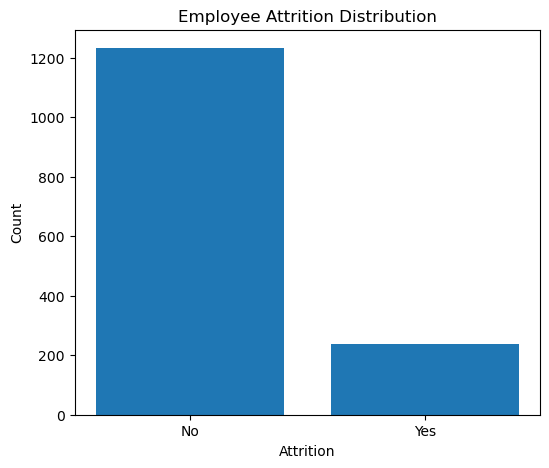

In [9]:
attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize = (6,5))

plt.bar(
    attrition_counts.index,
    attrition_counts.values
)

plt.xlabel('Attrition')
plt.ylabel('Count')
plt.title('Employee Attrition Distribution')

plt.show()

# 📌 Step 8 — Check Data Types

In [10]:
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

# 📌 Step 9 — Convert Target Variable

In [11]:
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

print(df['Attrition'].head())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


# 📌 Step 10 — Encode Categorical Columns

In [12]:
le = LabelEncoder()

#Find categorical columns
categorical_columns = df.select_dtypes(include = ['object']).columns

#Apply Label Encoding
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
    
print(df.head())

   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1               2       1102           2                 1   
1   49          0               1        279           1                 8   
2   37          1               2       1373           1                 2   
3   33          0               1       1392           1                 3   
4   27          0               2        591           1                 2   

   Education  EducationField  EmployeeCount  EmployeeNumber  ...  \
0          2               1              1               1  ...   
1          1               1              1               2  ...   
2          2               4              1               4  ...   
3          4               1              1               5  ...   
4          1               3              1               7  ...   

   RelationshipSatisfaction  StandardHours  StockOptionLevel  \
0                         1             80                

# 📌 Step 11 — Features and Target

In [13]:
#Independent Variables
X = df.drop('Attrition', axis = 1)

#Dependent Variable
y = df['Attrition']

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (1470, 34)
y Shape : (1470,)


# 📌 Step 12 — Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (1176, 34)
Testing Shape : (294, 34)


# 📌 Step 13 — Build Decision Tree Model

In [15]:
model = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 5,
    min_samples_split = 5,
    random_state = 42
)

#Train Model
model.fit(X_train, y_train)

print("Decision Tree Model Trained Sucessfully")

Decision Tree Model Trained Sucessfully


# 📌 Step 14 — Prediction

In [16]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


# 📌 Step 15 — Accuracy Score

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 0.8435374149659864


# 📌 Step 16 — Confusion Matrix

In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[239   8]
 [ 38   9]]


# 📌 Step 17 — Confusion Matrix Graph

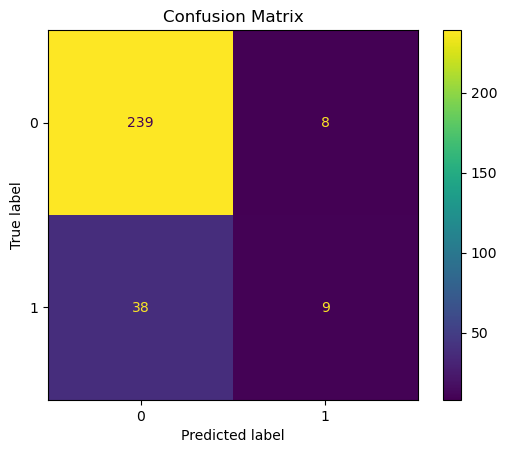

In [19]:
ConfusionMatrixDisplay(confusion_matrix = cm).plot()

plt.title("Confusion Matrix")

plt.show()

# 📌 Step 18 — Classification Report

In [20]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       247
           1       0.53      0.19      0.28        47

    accuracy                           0.84       294
   macro avg       0.70      0.58      0.60       294
weighted avg       0.81      0.84      0.81       294



# 📌 Step 19 — Feature Importance

In [21]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature' : X.columns, 
    'Importance' :importance 
})

feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending  = False
)

print(feature_importance.head(15))

                    Feature  Importance
27        TotalWorkingYears    0.244589
2                 DailyRate    0.130811
21                 OverTime    0.125711
17            MonthlyIncome    0.097348
0                       Age    0.087616
16            MaritalStatus    0.072149
11               HourlyRate    0.067997
19       NumCompaniesWorked    0.042606
31       YearsInCurrentRole    0.033951
9   EnvironmentSatisfaction    0.024576
29          WorkLifeBalance    0.023130
32  YearsSinceLastPromotion    0.019380
15          JobSatisfaction    0.015278
22        PercentSalaryHike    0.014859
30           YearsAtCompany    0.000000


# 📌 Step 20 — Feature Importance Graph

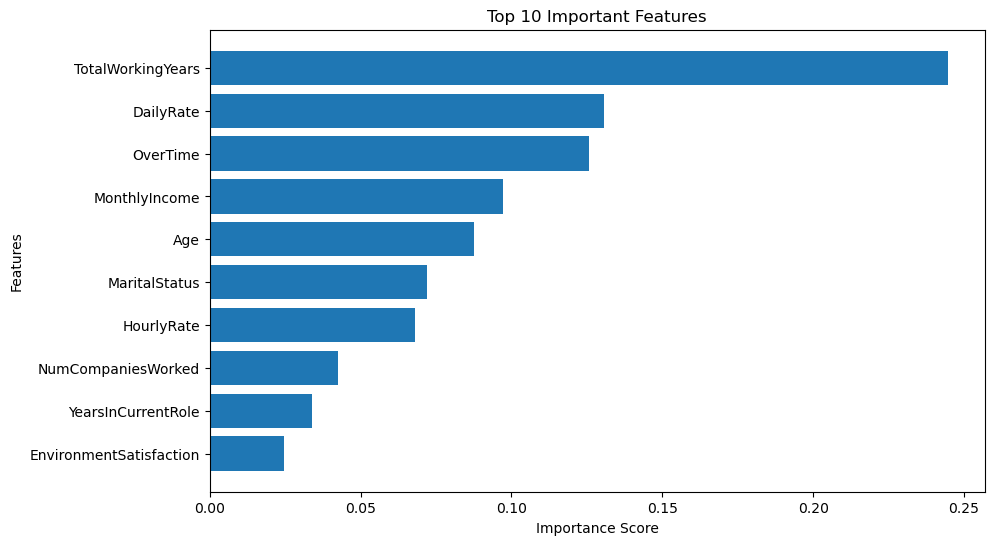

In [22]:
top_features = feature_importance.head(10)

plt.figure(figsize = (10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Important Features')

plt.gca().invert_yaxis()

plt.show()

# 📌 Step 21 — Decision Tree Visualization

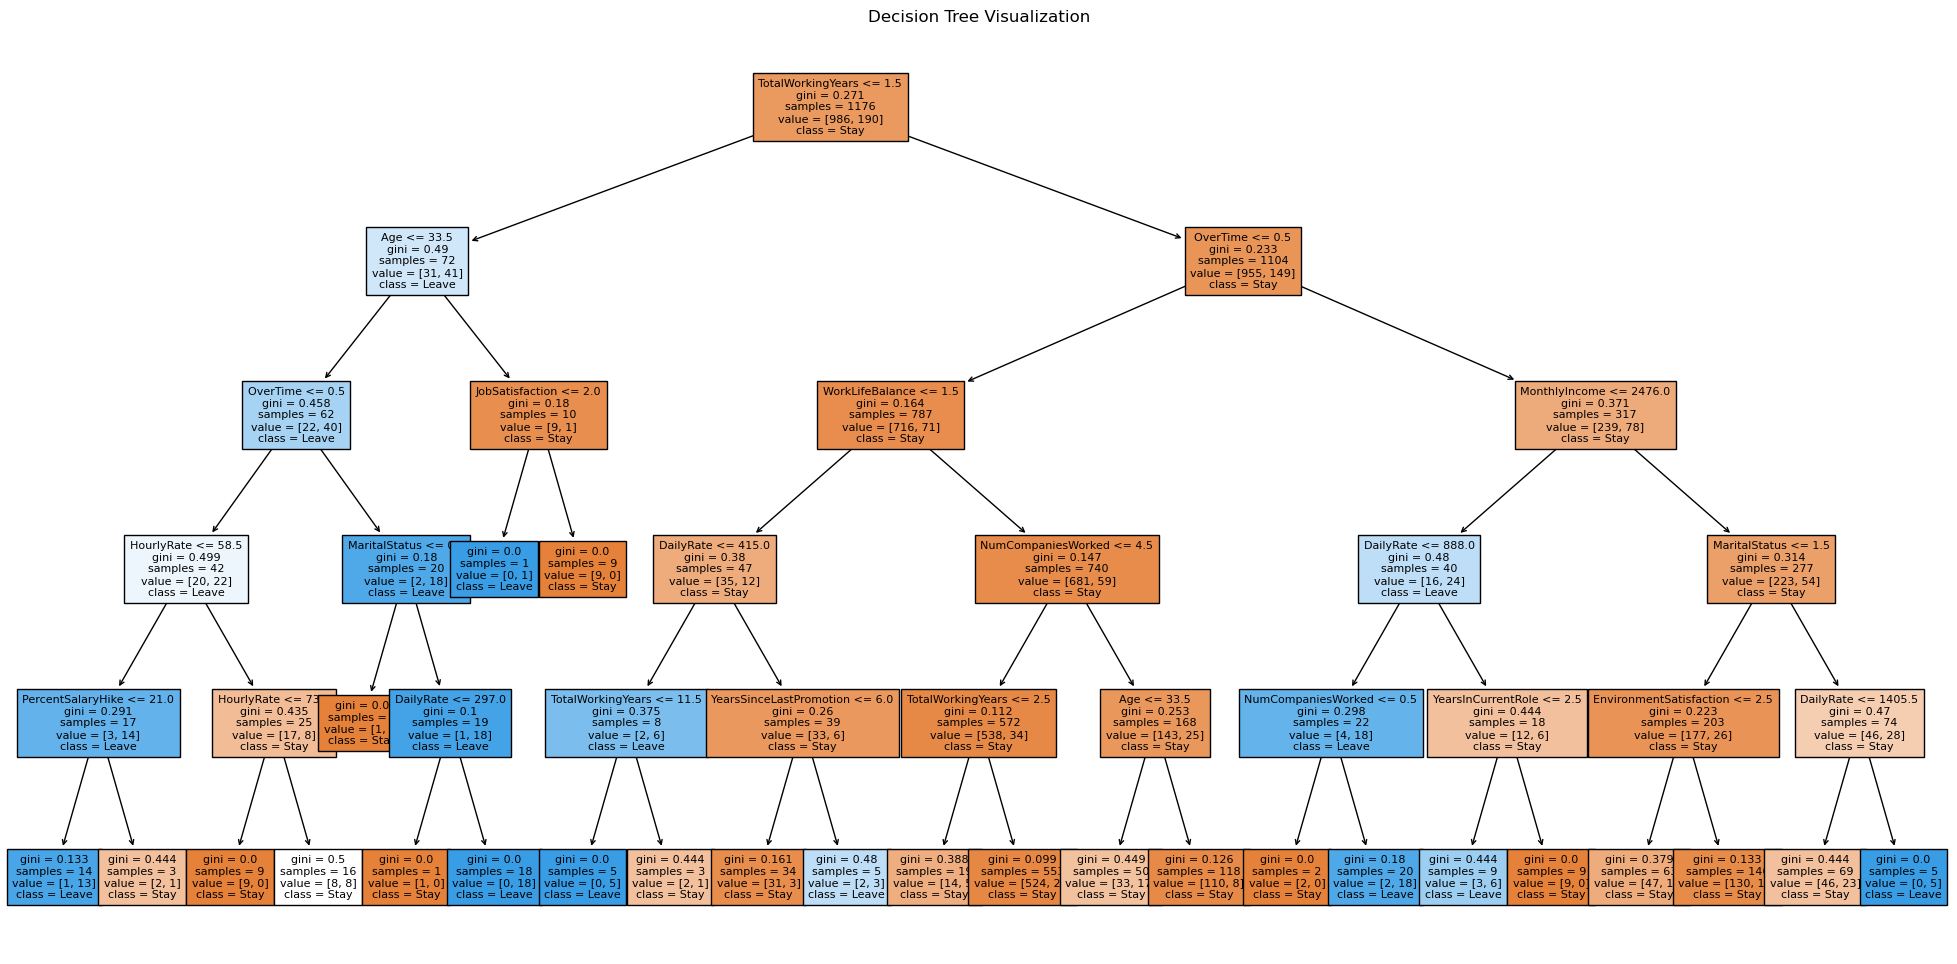

In [23]:
plt.figure(figsize = (25,12))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = ['Stay', 'Leave'],
    filled = True,
    fontsize = 8
)

plt.title('Decision Tree Visualization')

plt.show()

# 📌 Step 22 — Compare Actual vs Predicted

In [24]:
comparison = pd.DataFrame({
    'Actual' : y_test.values,
    'Predicted' : y_pred
})

print(comparison.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        1          0
5        0          0
6        0          0
7        0          0
8        0          0
9        0          1
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       0          0


# 📌 Step 23 — Predict New Employee Attrition

In [25]:
sample_data = X_test.iloc[0:1]

prediction = model.predict(sample_data)

print("Prediction :", prediction)

if prediction[0] == 1:
    print("Employee Will Leave")
    
else :
    print("Employee Will Stay")

Prediction : [0]
Employee Will Stay


# 📌 Step 24 — Overfitting Check

In [28]:
# Training Accuracy
train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

# Testing Accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy : 0.8903061224489796
Testing Accuracy : 0.8435374149659864


# 📌 Step 25 — Decision Tree Using Entropy

In [30]:
entropy_model = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth = 5,
    random_state = 42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Entropy Model Accuracy :", entropy_accuracy)

Entropy Model Accuracy : 0.8231292517006803


# 📌 Step 26 — Compare Gini vs Entropy

In [31]:
comparison_df = pd.DataFrame({
    'Model' : ['Gini', 'Entropy'],
    'Accuracy' : [test_accuracy, entropy_accuracy]
})

print(comparison_df)

     Model  Accuracy
0     Gini  0.843537
1  Entropy  0.823129


# 📌 Step 27 — Accuracy Comparison Graph

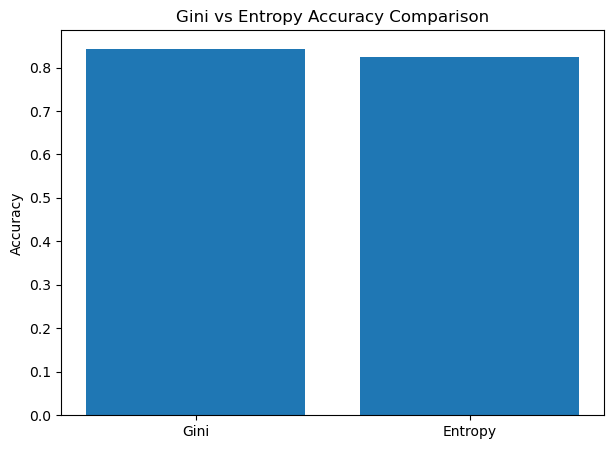

In [33]:
plt.figure(figsize = (7,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Accuracy']
)

plt.ylabel('Accuracy')
plt.title('Gini vs Entropy Accuracy Comparison')

plt.show()